In [3]:
from pathlib import Path
import sys

import lightning as L
import torch
import yaml

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

sys.path.append(str(Path("..").resolve()))
from pipeline import Pipeline  # noqa: E402

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def plot_multiclass_roc(probs, targets, class_names=None, figsize=(8, 6)):
    probs = np.asarray(probs)
    targets = np.asarray(targets)
    num_classes = probs.shape[1]
    targets_bin = label_binarize(
        targets,
        classes=np.arange(num_classes)
    )

    plt.figure(figsize=figsize)
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(
            targets_bin[:, i],
            probs[:, i]
        )

        roc_auc = auc(fpr, tpr)

        label = (
            class_names[i] if class_names is not None else f"Class {i}"
        )

        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC")
    plt.legend()
    plt.grid(True)
    plt.show()



def plot_latest_lightning_run(log_dir="lightning_logs"):
    log_dir = Path(log_dir)

    # collect all version folders
    versions = sorted(
        [p for p in log_dir.glob("version_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime
    )

    if not versions:
        raise FileNotFoundError(f"No Lightning versions found in {log_dir}")

    latest_run = versions[-1]
    csv_path = latest_run / "metrics.csv"

    if not csv_path.exists():
        raise FileNotFoundError(f"No metrics.csv in {latest_run}")

    df = pd.read_csv(csv_path)

    print(df.columns.tolist())
    print(df.head())        #!!!!!!!!!!!!!!!!!!!!!


    train = df.dropna(subset=["train_loss_epoch"])
    val = df.dropna(subset=["val_loss"])

    plt.figure(figsize=(8, 5))

    if len(train) > 0:
        plt.plot(train["epoch"], train["train_loss_epoch"], label="train loss")

    if len(val) > 0:
        plt.plot(val["epoch"], val["val_loss"], label="val loss")

    plt.grid(alpha=0.4, ls="--")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Run: {latest_run.name}")
    plt.legend()
    plt.ylim(0, 3)
    plt.show()  

In [ ]:
config_path = Path("configs/config.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

L.seed_everything(config["training"].get("seed", 42), workers=True)

pipeline = Pipeline(config)
outputs = pipeline.run()

[rank: 0] Seed set to 42
/gpfs/home2/scur0057/conda/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/home2/scur0057/conda/lib/python3.13/site-packa ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/gpfs/home2/scur0057/conda/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enabl

/gpfs/home2/scur0057/ML_project/configs/config.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


/gpfs/home2/scur0057/ML_project/scs/model.py:348: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Dataset sizes:
Train: 299880
Val:   64260
Test:  64260


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/home2/scur0057/conda/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | Model            | 1.9 M  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.416     Total estimated model params size (MB)
53        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/gpfs/home2/scur0057/conda/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/gpfs/home2/scur0057/conda/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 13:   0%|          | 1/585 [00:01<09:47,  0.99it/s, v_num=29, train_loss_step=1.060, train_acc_step=0.623, train_loss_epoch=1.020, train_acc_epoch=0.631]  

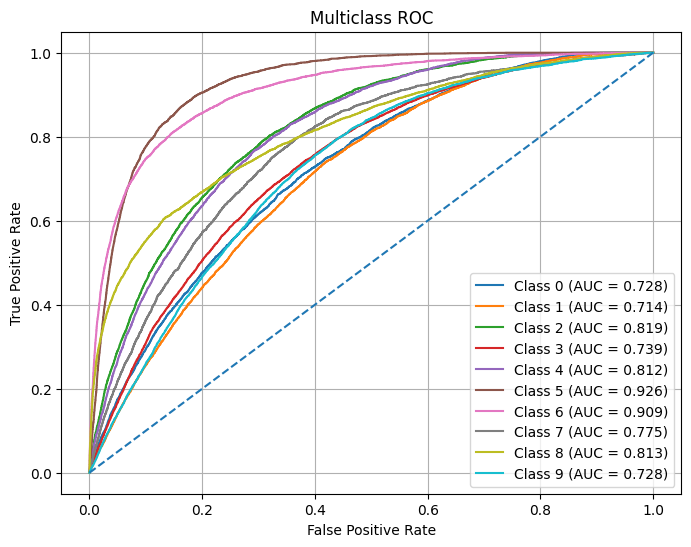

['epoch', 'step', 'test_acc', 'test_loss', 'train_acc_epoch', 'train_acc_step', 'train_loss_epoch', 'train_loss_step']
   epoch  step  test_acc  test_loss  train_acc_epoch  train_acc_step  \
0      0     9       NaN        NaN              NaN        0.390625   
1      0    19       NaN        NaN              NaN        0.000000   
2      0    29       NaN        NaN              NaN        0.000000   
3      0    39       NaN        NaN              NaN        0.000000   
4      0    49       NaN        NaN              NaN        0.000000   

   train_loss_epoch  train_loss_step  
0               NaN         2.564295  
1               NaN         2.260159  
2               NaN         2.746010  
3               NaN         2.469624  
4               NaN         3.741856  


KeyError: ['val_loss_epoch']

In [ ]:
trainer = pipeline.lightning_model
probs = torch.cat(trainer.test_probs).numpy()
targets = torch.cat(trainer.test_targets).numpy()

plot_multiclass_roc(probs, targets)

plot_latest_lightning_run()